In [2]:
import os
import sys
from ipywidgets import interact

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_notebook import *

%matplotlib widget

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000, -0.8889, -0.8889,  1.0000,  0.5482, -0.8364],
        [ 0.0000,  1.0000,  0.0000, -0.2222,  0.0000, -1.0000, -0.6021, -0.7985],
        [ 1.0000,  0.0000,  0.0000, -0.6667, -0.3333, -0.7143,  0.5432, -0.8396]])
tensor([[-2.7888, -0.0430, -0.6703, -0.9738, -0.0333, -0.4771,  0.8494, -0.8326],
        [ 1.0666,  1.5134, -0.7377,  0.6784,  0.8250, -0.5164,  0.7534,  0.8697],
        [-0.0945,  0.0224, -1.0067, -0.0731,  0.0174, -0.6526,  0.8993, -0.4532]],
       device='cuda:0')


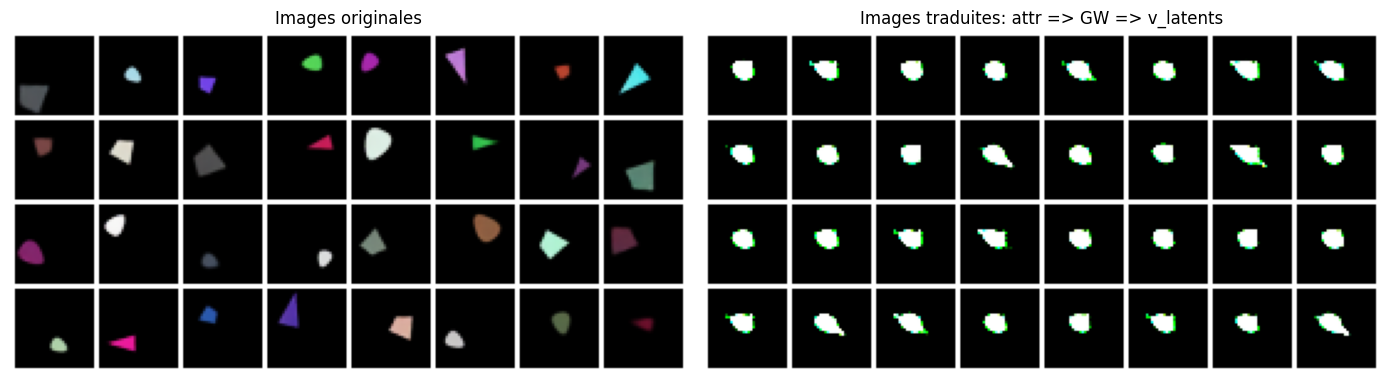

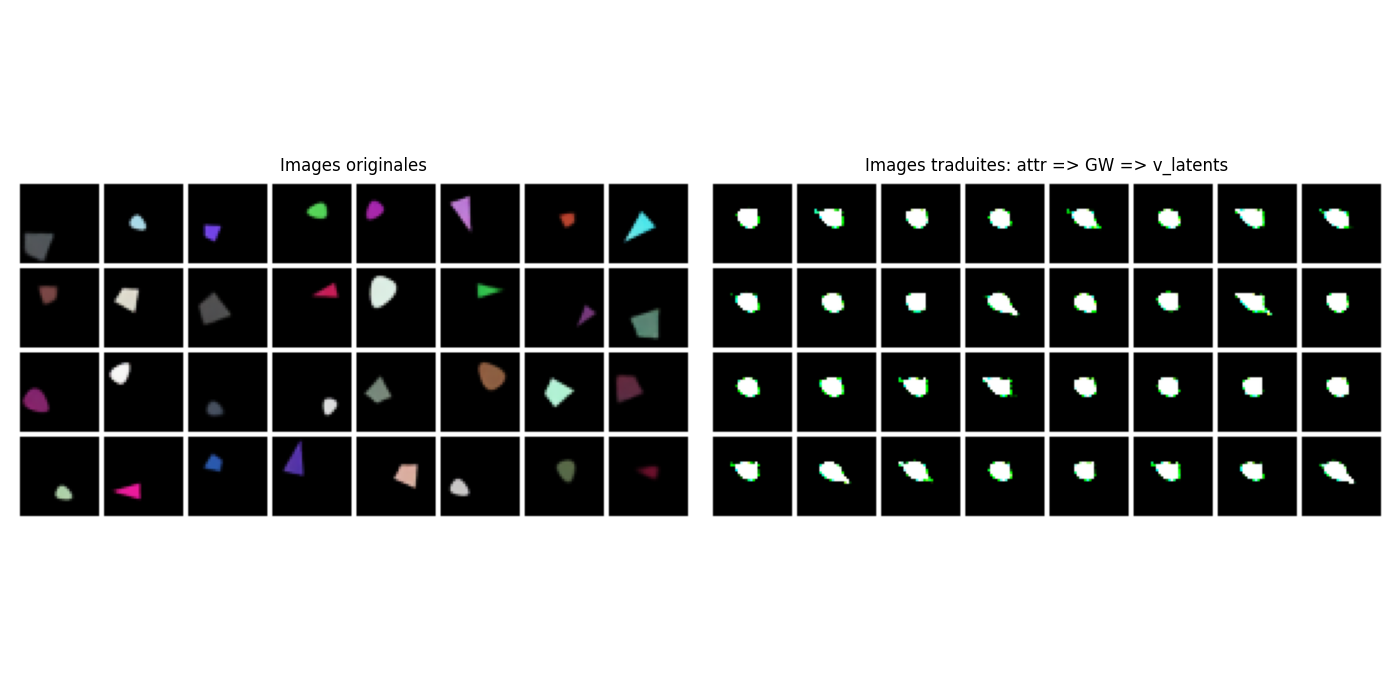

In [8]:
project_name = "syn"
condition = "debug"
data = "test1"
switch_epoch = 10000

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples, split ='train')
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [9]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image_from_interactive_attr(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image_from_interactive_attr(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…